# Histogram and equalization

A histogram is a column or line chart that represents the distribution of pixel values in an image. It shows the number of lighter pixels (close to 255) and the number of darker pixels (close to 0).

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

In [2]:
image = cv2.imread('images/kayak.png')

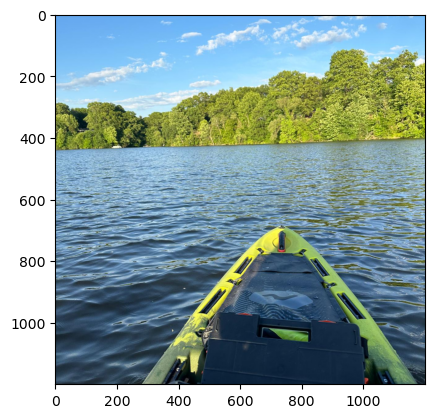

In [4]:
rgbImage = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(rgbImage)
plt.show()

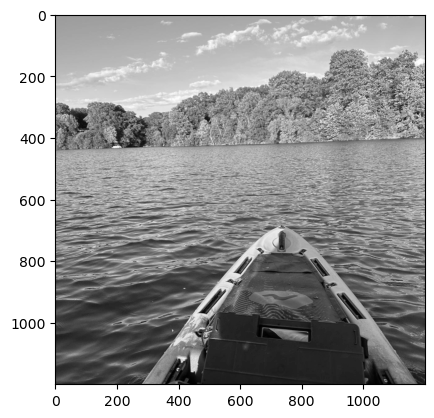

In [5]:
grayImage = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.imshow(grayImage, cmap ='gray')
plt.show()

### Histogram calculation
See https://docs.opencv.org/3.4/d8/dbc/tutorial_histogram_calculation.html

b_hist = cv2.calcHist([img], channels=[0], mask=None, histSize=[256], ranges=[0,256])

b_hist = cv.calcHist([bgr_image], [0], None, [histSize], histRange) <br>
g_hist = cv.calcHist([bgr_image], [1], None, [histSize], histRange) <br>
r_hist = cv.calcHist([bgr_image], [2], None, [histSize], histRange) <br>

#### Histogram for gray images

In [6]:
hist = cv2.calcHist([grayImage], channels=[0], mask = None, histSize=[256], ranges= [0,256])

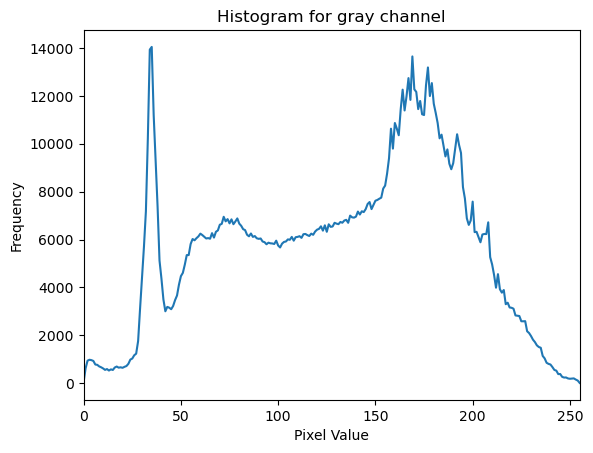

In [7]:
plt.figure() 
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Histogram for gray channel')
plt.plot(hist) 
plt.xlim([0,255]) 
plt.show()

#### Histogram of color images

In [8]:
rHist = cv2.calcHist([rgbImage], channels=[0], mask = None, histSize=[256], ranges= [0,256])
gHist = cv2.calcHist([rgbImage], channels=[1], mask = None, histSize=[256], ranges= [0,256])
bHist = cv2.calcHist([rgbImage], channels=[2], mask = None, histSize=[256], ranges= [0,256])


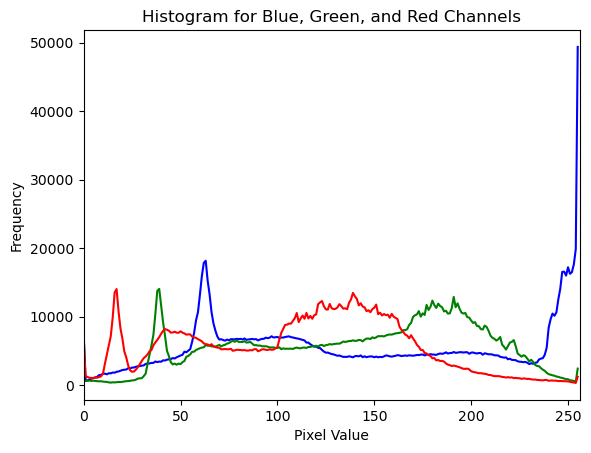

In [9]:
plt.plot(bHist, color='blue')
plt.plot(gHist, color='green')
plt.plot(rHist, color='red')

plt.xlim([0,256])
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Histogram for Blue, Green, and Red Channels')
plt.show()

# Histogram equalization

Histogram equalization is an image processing technique that adjusts the contrast of an image by redistributing the pixel intensity values. <br>
Histogram equalization can improve the contrast of low-contrast images, making details more visible. For example, in a medical X-ray image, equalization can help highlight details of bones or soft tissues that are crucial for an accurate diagnosis.

In [10]:
from skimage import data
camera = data.camera()

C:\Users\Levi\miniconda3\envs\text-media\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


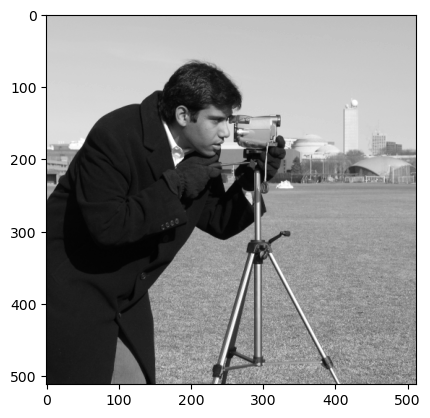

In [13]:
plt.imshow(camera, cmap = "gray")
plt.show()

In [14]:
hist = cv2.calcHist([camera], channels=[0], mask = None, histSize=[256], ranges= [0,256])

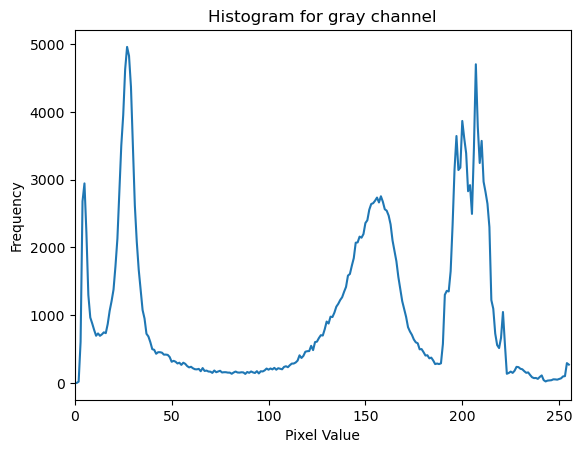

In [15]:
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Histogram for gray channel')
plt.plot(hist) 
plt.xlim([0,256]) 
plt.show()

In [17]:
camera_eq = cv2.equalizeHist(camera)
hist = cv2.calcHist([camera_eq], channels=[0], mask = None, histSize=[256], ranges= [0,256])

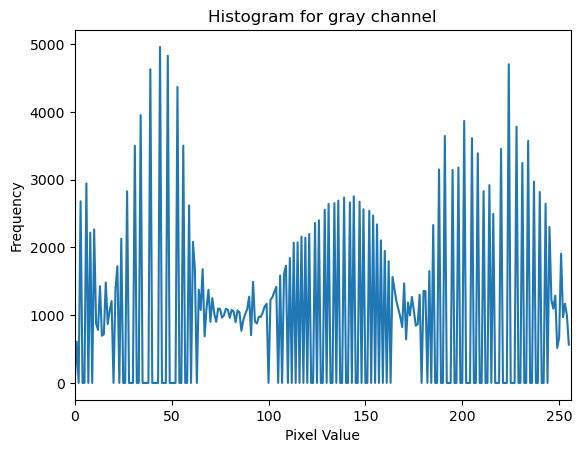

In [18]:
plt.xlabel('Pixel Value')
plt.ylabel('Frequency')
plt.title('Histogram for gray channel')
plt.plot(hist) 
plt.xlim([0,256]) 
plt.show()

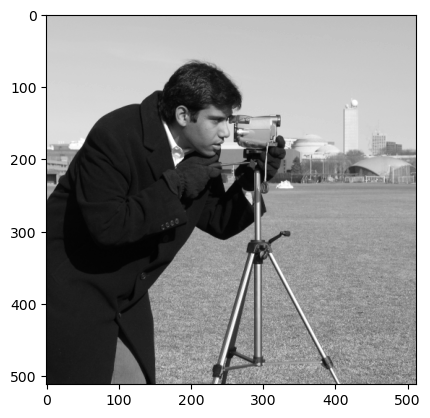

In [21]:
plt.imshow(camera, cmap='gray')
plt.show()

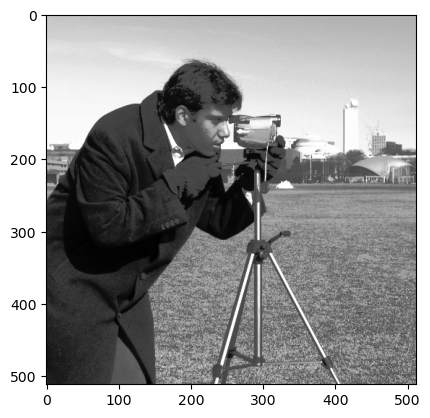

In [22]:
plt.imshow(camera_eq, cmap='gray')
plt.show()

Distortions and color changes may occur in the equalized image, so the image may not always retain its original characteristics. However, if it is necessary to highlight details in the image, equalization can be a great ally. 